# Robot anatomy


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import argparse
import ipywidgets as widgets
from ipywidgets import interact, fixed

## Functions

In [10]:
def timestamp_converter(x):
    s = str(x, 'utf-8')
    print(f"Converting timestamp: {s}")
    if s == "timestamp":
        return 0.0
    else:
        return float(s)

def compute_avg_theta(data: np.ndarray):
    jumps = np.diff(data)

    # Handle 360-degree wraparound
    jumps[jumps < 0] += 360.0

    return np.mean(jumps)
def shift_angles(angles, shift_deg):
    return (angles + shift_deg) % 360


In [11]:

def compute_boxplot_stats(binData):
    outlier_percentage = 0
    coefVariation = 0
    avgs = 0

    if len(binData) == 0:
        outlier_count = 0
        coefVariation = 0
        avgs = 0
        return avgs, coefVariation, outlier_count

    # average
    avgs = np.mean(binData)

    # standard deviation
    std = np.std(binData)
    coefVariation = std / (np.mean(binData) + 1e-6)
    

    # quartiles
    q1 = np.percentile(binData, 25)
    q3 = np.percentile(binData, 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # outliers
    outliers = binData[(binData < lower) | (binData > upper)]
    outlier_percentage = len(outliers) / len(binData) 

    return  avgs, std, coefVariation, outlier_percentage

In [12]:
def plot_precision(angles: np.ndarray, 
                   quality: np.ndarray, 
                   distances: np.ndarray,
                    ax_avg: plt.Axes,
                    ax_cov: plt.Axes,
                    ax_out: plt.Axes,
                    ax_qual: plt.Axes,  
                    fig_precision: plt.Figure,         
                   bin_res):
    ax_avg.cla()
    ax_cov.cla()
    ax_out.cla()
    ax_qual.cla()
    # Compute bins:
    bins = np.arange(0, 360 + bin_res, bin_res)
    
    stats_per_bin = np.zeros((len(bins) - 1, 4))  # columns: avg, std, coefVariation, outlier_percentage
    quality_per_bin = np.zeros(len(bins) - 1)
    
    for bin_start, bin_end in zip(bins[:-1], bins[1:]):
        indices = np.where((angles >= bin_start) & (angles < bin_end))[0]
        if len(indices) > 0:
            valid_mask = quality[indices] != 0
            valid_indices = indices[valid_mask]  # indices into original arrays
            
            quality_per_bin[int(bin_start // bin_res)] = len(valid_indices) / len(indices)
            
            if len(valid_indices) > 0:
                avgs, std, coefVariation, outlier_percentages = compute_boxplot_stats(distances[valid_indices])
                stats_per_bin[int(bin_start // bin_res)] = [avgs, std, coefVariation, outlier_percentages]
            else:
                stats_per_bin[int(bin_start // bin_res)] = [0, 0, 0, 0]
        else:
            quality_per_bin[int(bin_start // bin_res)] = 0
            stats_per_bin[int(bin_start // bin_res)] = [0, 0, 0, 0]

    # Create polar plot 
    thetaAxis = np.deg2rad(bins[:-1])  # Convert bin edges to radians for polar plot
    
    r_mean = stats_per_bin[:, 0]
    r_std  = stats_per_bin[:, 1]
    r_lower = np.maximum(r_mean - r_std, 0) 

    # Close the loop so fill wraps around 360°
    theta_closed = np.concatenate([thetaAxis, thetaAxis[::-1]])
    r_closed     = np.concatenate([r_mean + r_std, r_lower[::-1]])

    # ---- AX1: Polar Plot ----
    ax_avg.fill(theta_closed, r_closed, color='blue', alpha=0.25)
    ax_avg.plot(thetaAxis, r_mean, color='blue', linewidth=1)
    
    ax_avg.set_title("Radial Average Distance ± Std Dev")
    ax_avg.set_theta_zero_location("N")
    ax_avg.set_theta_direction(-1)
    
    # ---- AX2: CV Bar Plot ----
    ax_cov.bar(bins[:-1], stats_per_bin[:, 2], width=bin_res, color='tomato', align='edge')
    ax_cov.set_xlabel('Angle (degrees)')
    ax_cov.set_ylabel('Coefficient of Variation (log scale)')
    ax_cov.set_title('LiDAR Coefficient of Variation per Angle Bin')
    ax_cov.set_yscale('log')
    ax_cov.set_ylim(1e-3, 1e1)
    ax_cov.grid(True, which='both')  # 'both' shows minor grid lines too, useful for log scale

    # ---- AX3: Outliers Bar Plot ----
    ax_out.bar(bins[:-1], stats_per_bin[:, 3], width=bin_res, align='edge')
    ax_out.set_xlabel('Angle (degrees)')
    ax_out.set_ylabel('Outlier Percentage')
    ax_out.set_ylim(0, 1)  
    ax_out.set_title('LiDAR Outlier Percentage per Angle Bin')
    ax_out.grid(True)

    # ---- AX4: Quality Line Plot ----
    ax_qual.plot(bins[:-1], quality_per_bin, marker='o', color='purple')
    ax_qual.set_xlabel('Angle (degrees)')
    ax_qual.set_ylabel('Quality')
    ax_qual.set_title('LiDAR Quality per Angle Bin')
    ax_qual.grid(True)
    
    # 2. Force layout clean up and draw the update
    fig_precision.tight_layout()
    fig_precision.canvas.draw_idle()

In [13]:
def plot_raw(df: pd.DataFrame, timeRange ):
    ax_noise.cla()
    
    t_start = pd.to_datetime(timeRange[0]*1000, unit='s')
    t_end   = pd.to_datetime(timeRange[1]*1000, unit='s') #timeRange[1] #

    indices = np.where((df["timestamp"] >= t_start) & (df["timestamp"] < t_end))[0]

    sc = ax_noise.scatter(
        np.deg2rad(df["theta"].iloc[indices]),
        df["dist_mm"].iloc[indices],
        s=3,
        alpha=0.1
    )
    ax_noise.set_theta_zero_location("N")
    ax_noise.set_theta_direction(-1)
    figRaw.canvas.draw_idle()


## Interactive

In [14]:
binSlider = widgets.FloatSlider(value=0.4, min=0, max=5, step=0.2, description='Bin resolution:')

timeSlider = widgets.FloatRangeSlider(
    value=[0, 350],
    min=0,
    max=355.0,
    step=1.0,
    description='Time range:',
    continuous_update=False,
    orientation='horizontal',
    layout=widgets.Layout(width='80%')
)

filename="data/control_1_2v.csv"

df = pd.read_csv(filename, delimiter=",")

df["timestamp"] = df["timestamp"] - df["timestamp"].min()
df["timestamp"] = pd.to_datetime(df["timestamp"], unit='s')

print("Average theta jump: ", compute_avg_theta(df["theta"].to_numpy()))


Average theta jump:  0.23915972149504153


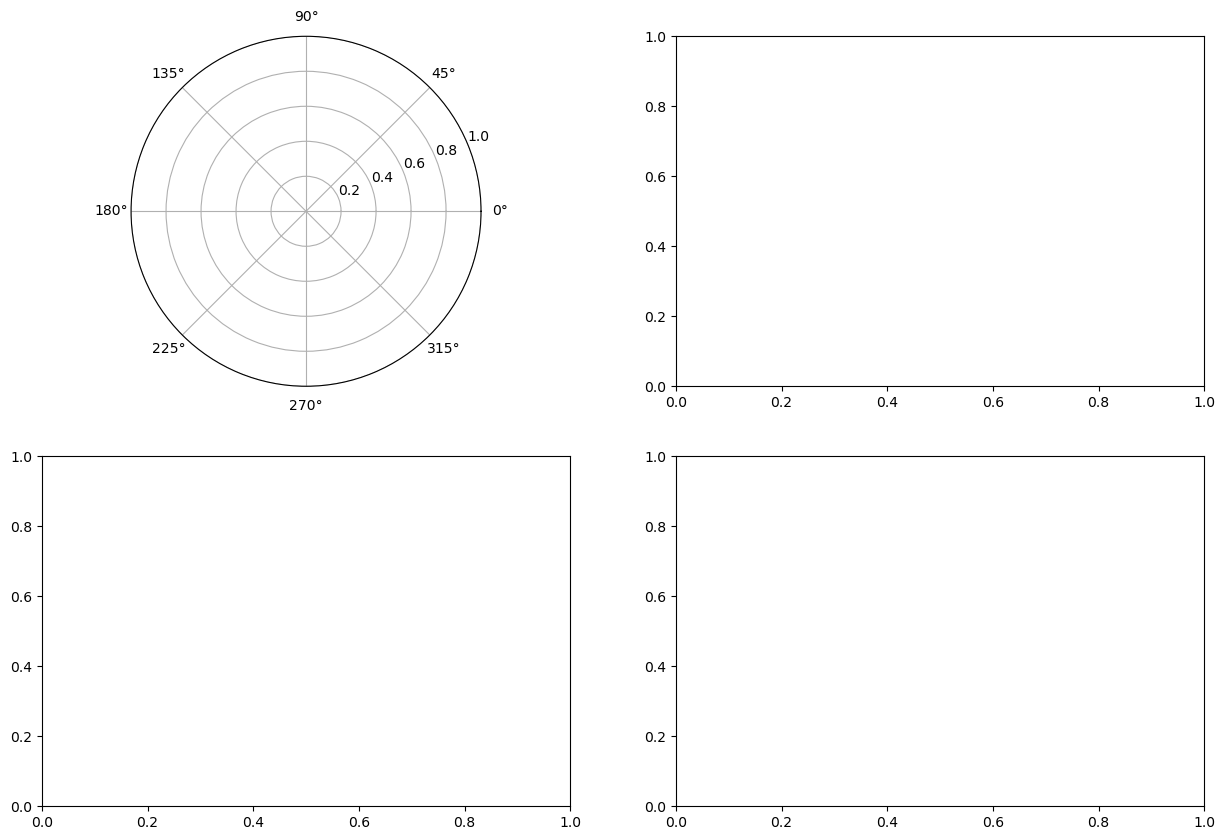

interactive(children=(FloatSlider(value=0.4, description='Bin resolution:', max=5.0, step=0.2), Output()), _do…

<function __main__.plot_precision(angles: numpy.ndarray, quality: numpy.ndarray, distances: numpy.ndarray, ax_avg: matplotlib.axes._axes.Axes, ax_cov: matplotlib.axes._axes.Axes, ax_out: matplotlib.axes._axes.Axes, ax_qual: matplotlib.axes._axes.Axes, fig_precision: matplotlib.figure.Figure, bin_res)>

In [15]:
# Load data from file

fig_precision = plt.figure(figsize=(15, 10))
ax_avg  = fig_precision.add_subplot(2, 2, 1, projection='polar')
ax_cov  = fig_precision.add_subplot(2, 2, 2)
ax_out  = fig_precision.add_subplot(2, 2, 3)
ax_qual = fig_precision.add_subplot(2, 2, 4)

# Note: Pass binSlider itself (the widget), not binSlider.value!
interact(
    plot_precision, 
    bin_res=binSlider,
    angles=fixed(df["theta"].to_numpy()), 
    quality=fixed(df["quality"].to_numpy()), 
    distances=fixed(df["dist_mm"].to_numpy()),
    ax_avg=fixed(ax_avg),
    ax_cov=fixed(ax_cov),
    ax_out=fixed(ax_out),
    ax_qual=fixed(ax_qual),
    fig_precision=fixed(fig_precision)
)

### Raw data

0         1970-01-01 00:00:00
1         1970-01-01 00:00:00
2         1970-01-01 00:00:00
3         1970-01-01 00:00:00
4         1970-01-01 00:00:00
                  ...        
1165074   1970-01-04 10:42:08
1165075   1970-01-04 10:42:08
1165076   1970-01-04 10:42:08
1165077   1970-01-04 10:42:08
1165078   1970-01-04 10:42:08
Name: timestamp, Length: 1165079, dtype: datetime64[s]

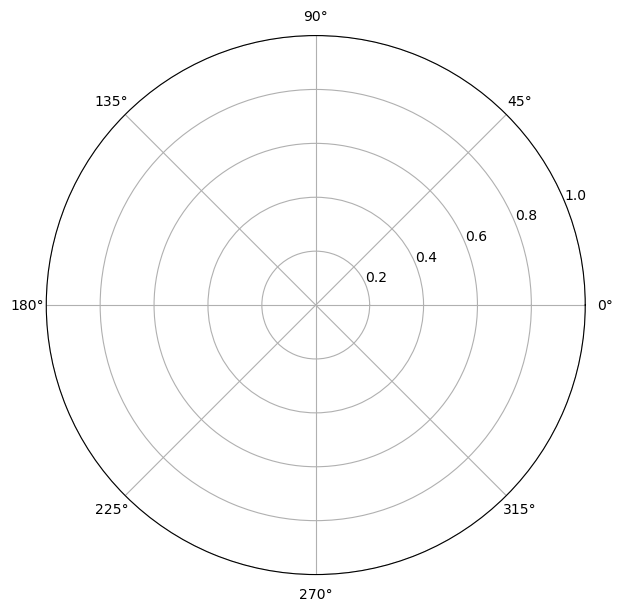

interactive(children=(FloatRangeSlider(value=(0.0, 350.0), continuous_update=False, description='Time range:',…

In [16]:
display(df["timestamp"])
figRaw = plt.figure(figsize=(7, 7))
ax_noise = figRaw.add_subplot(111, projection='polar')

interact(
    plot_raw, 
    timeRange=timeSlider,
    df=fixed(df)
)
plt.show()